<a href="https://colab.research.google.com/github/PriscillaAfuaArhin/NLP-LLM/blob/main/NLP%26LLM_text_classification_pytorch_assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Classification: Classical ML, RNN, and CNN
## NLP at AIMS South Africa 2025
### Based on Lecture 05: Sequence Modeling

This notebook demonstrates sentiment classification using three approaches:
1. **Classical ML** (baseline for comparison)
2. **Recurrent Neural Networks (RNN/LSTM)**
3. **Convolutional Neural Networks (CNN)**

**Dataset**: HausaNLP/AfriSenti-Twitter (Sentiment analysis on African languages)

## 1. Setup and Data Loading

In [1]:
# Install required packages
!pip install datasets torch scikit-learn pandas numpy matplotlib seaborn torchtext -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.10.0+cpu


In [3]:
# Load AfriSenti-Twitter dataset directly from GitHub
# Note: HuggingFace no longer supports dataset scripts, so we load directly from the repository

LANG = 'twi'  # Hausa language
BASE_URL = f"https://raw.githubusercontent.com/afrisenti-semeval/afrisent-semeval-2023/main/data/{LANG}"

# Load the data using pandas
train_df = pd.read_csv(f"{BASE_URL}/train.tsv", sep='\t')
val_df = pd.read_csv(f"{BASE_URL}/dev.tsv", sep='\t')
test_df = pd.read_csv(f"{BASE_URL}/test.tsv", sep='\t')

print("Dataset loaded successfully!")
print(f"\nTraining set shape: {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")
print(f"Test set shape: {test_df.shape}")
print("\nColumns:", train_df.columns.tolist())
print("\nSample from training set:")
print(train_df.head(3))

Dataset loaded successfully!

Training set shape: (3481, 2)
Validation set shape: (388, 2)
Test set shape: (949, 2)

Columns: ['tweet', 'label']

Sample from training set:
                                               tweet     label
0                        kako be shark but wo ti ewu  negative
1            br ne bayie nti na me supporti man city  negative
2  s3 woofis3 mada wafutuo tantan no 3y3wo s3mafa...  negative


The dataset was successfully loaded and prepared for sentiment analysis. It contains tweets in Twi language along with their corresponding sentiment labels, which will be used to train and evaluate the models. The tweets reflect informal social media language, including slang and variations in spelling, which makes the classification task more challenging. This dataset therefore provides a realistic scenario for testing the performance of different NLP models on sentiment classification.


In [4]:
# Extract texts and labels
train_texts = train_df['tweet'].tolist()
train_labels = train_df['label'].tolist()

val_texts = val_df['tweet'].tolist()
val_labels = val_df['label'].tolist()

test_texts = test_df['tweet'].tolist()
test_labels = test_df['label'].tolist()

print(f"Training samples: {len(train_texts)}")
print(f"Validation samples: {len(val_texts)}")
print(f"Test samples: {len(test_texts)}")

# Check label distribution
label_names = ['positive', 'neutral', 'negative']
print("\nLabel distribution in training set:")
for i, name in enumerate(label_names):
    count = train_labels.count(name)
    print(f"{name}: {count} ({count/len(train_labels)*100:.1f}%)")

Training samples: 3481
Validation samples: 388
Test samples: 949

Label distribution in training set:
positive: 1644 (47.2%)
neutral: 522 (15.0%)
negative: 1315 (37.8%)


The label distribution shows that positive tweets are the most frequent, followed by negative tweets, while neutral tweets appear much less often. This indicates that the dataset is not perfectly balanced, since one class (neutral) has significantly fewer examples than the others.

Such imbalance can influence model performance, as models may learn the majority classes more easily while struggling to correctly predict the minority class.

## 2. Classical Machine Learning (Baseline)

**Why Classical ML?**
- Fast to train
- Interpretable
- Good baseline for comparison

**Limitation**: Treats text as bag-of-words (ignores word order and context)

We'll use TF-IDF features with three classifiers:
- Logistic Regression
- Naive Bayes
- Linear SVM

In [5]:
# Vectorize text using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)
X_test = vectorizer.transform(test_texts)

y_train = np.array(train_labels)
y_val = np.array(val_labels)
y_test = np.array(test_labels)

print(f"TF-IDF feature matrix shape: {X_train.shape}")

TF-IDF feature matrix shape: (3481, 5000)


In [6]:
# Train and evaluate classical ML models
classical_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(random_state=42, max_iter=1000)
}

classical_results = {}

for name, model in classical_models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    classical_results[name] = accuracy

    print(f"\nTest Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_names))


Training Logistic Regression...

Test Accuracy: 0.6565

Classification Report:
              precision    recall  f1-score   support

    positive       0.66      0.69      0.68       353
     neutral       0.28      0.03      0.06       146
    negative       0.67      0.83      0.74       450

    accuracy                           0.66       949
   macro avg       0.53      0.52      0.49       949
weighted avg       0.60      0.66      0.61       949


Training Naive Bayes...

Test Accuracy: 0.6607

Classification Report:
              precision    recall  f1-score   support

    positive       0.69      0.67      0.68       353
     neutral       0.00      0.00      0.00       146
    negative       0.64      0.87      0.74       450

    accuracy                           0.66       949
   macro avg       0.44      0.51      0.47       949
weighted avg       0.56      0.66      0.60       949


Training Linear SVM...

Test Accuracy: 0.6249

Classification Report:
              p

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Interpretation**

Three classical models were trained: Logistic Regression, Naive Bayes, and Linear SVM. Logistic Regression and Naive Bayes achieved similar accuracy and performed slightly better than Linear SVM.

The models predicted **positive and negative sentiments fairly well**, but they **struggled to correctly classify neutral tweets**. This is likely because the neutral class has fewer examples in the dataset.

Overall, the results show that classical models using TF-IDF features can capture basic sentiment patterns but have difficulty handling class imbalance and subtle sentiment differences.


### Key Takeaway: Classical ML Limitations

**Example demonstrating bag-of-words limitation:**
- "Football makes people happy."
- "People make football happy."

Both sentences contain identical words, so bag-of-words models treat them as the same, even though their meanings differ. This is where sequence models (RNN/CNN) excel.

## 3. Text Preprocessing for Neural Networks

In [7]:
# Build vocabulary
class Vocabulary:
    def __init__(self, max_size=5000):
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.max_size = max_size

    def build_vocab(self, texts):
        """Build vocabulary from texts"""
        # Count word frequencies
        word_counts = Counter()
        for text in texts:
            words = text.lower().split()
            word_counts.update(words)

        # Get most common words
        most_common = word_counts.most_common(self.max_size - 2)  # -2 for PAD and UNK

        # Build mappings
        for idx, (word, _) in enumerate(most_common, start=2):
            self.word2idx[word] = idx
            self.idx2word[idx] = word

    def encode(self, text):
        """Convert text to indices"""
        words = text.lower().split()
        return [self.word2idx.get(word, 1) for word in words]  # 1 is <UNK>

    def __len__(self):
        return len(self.word2idx)

# Build vocabulary
vocab = Vocabulary(max_size=5000)
vocab.build_vocab(train_texts)

print(f"Vocabulary size: {len(vocab)}")
print(f"Sample encoding: {train_texts[0][:50]}...")
print(f"Encoded: {vocab.encode(train_texts[0])[:10]}...")

Vocabulary size: 5000
Sample encoding: kako be shark but wo ti ewu...
Encoded: [1704, 65, 3274, 107, 3, 87, 669]...


The vocabulary was limited to the most frequent words in the dataset. Each word in the vocabulary is assigned a unique numerical index.

The example shows how a tweet is converted into a sequence of numbers, where each number represents a word from the vocabulary. This numerical encoding allows neural network models such as RNNs and CNNs to process the text data during training.

In [8]:
# PyTorch Dataset class
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.vocab.encode(self.texts[idx])
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

# Collate function for padding
def collate_batch(batch):
    texts, labels = zip(*batch)
    texts = pad_sequence(texts, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    return texts, labels

# Create datasets
train_dataset = TextDataset(train_texts, train_labels, vocab)
val_dataset = TextDataset(val_texts, val_labels, vocab)
test_dataset = TextDataset(test_texts, test_labels, vocab)

# Create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 109
Number of validation batches: 13
Number of test batches: 30


**Interpretation**

The dataset was divided into batches to make training more efficient. Each batch contains a group of tweets that are processed together during model training and evaluation.

The number of batches indicates how many groups of data the model will process in each phase. This batching approach helps improve training speed and allows the model to learn from the data in manageable portions.


## 4. Recurrent Neural Network (RNN/LSTM)

**Why RNN for Text?**
- Processes input **sequentially** (word by word)
- Maintains **memory** of previous words via hidden states
- Captures **long-range dependencies** and temporal relationships
- Handles **variable-length** input naturally

**LSTM** (Long Short-Term Memory) is used to solve the vanishing gradient problem in vanilla RNNs.

**Architecture**:
1. Embedding Layer: Converts words to dense vectors
2. LSTM Layer: Processes sequences and captures temporal patterns
3. Dense Layer: Classification head

In [11]:
# Build RNN/LSTM model
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=1, dropout=0.2):
        super(LSTMClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers,
                           batch_first=True, dropout=dropout if n_layers > 1 else 0,
                           bidirectional=False)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, output_dim)
        self.relu = nn.ReLU()

    def forward(self, text):
        # text: [batch_size, seq_len]
        embedded = self.embedding(text)  # [batch_size, seq_len, embedding_dim]

        # LSTM output
        lstm_out, (hidden, cell) = self.lstm(embedded)  # lstm_out: [batch_size, seq_len, hidden_dim]

        # Use the last hidden state
        hidden = hidden[-1]  # [batch_size, hidden_dim]

        # Fully connected layers
        x = self.relu(self.fc1(hidden))
        x = self.dropout(x)
        output = self.fc2(x)  # [batch_size, output_dim]

        return output

# Model parameters
EMBEDDING_DIM = 128
HIDDEN_DIM = 64
OUTPUT_DIM = 3
N_LAYERS = 1
DROPOUT = 0.2

# Create model
rnn_model = LSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT
).to(device)

print(rnn_model)
print(f"\nTotal parameters: {sum(p.numel() for p in rnn_model.parameters()):,}")

LSTMClassifier(
  (embedding): Embedding(5000, 128, padding_idx=0)
  (lstm): LSTM(128, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=32, out_features=3, bias=True)
  (relu): ReLU()
)

Total parameters: 691,843


**Interpretation**

The model is an **LSTM neural network used for sentiment classification**.

The embedding layer converts words into vectors, the LSTM layer learns patterns and word order in the tweets, and the final layers classify the tweet into **positive, neutral, or negative sentiment**.

The model has many trainable parameters, allowing it to learn complex patterns in the text data.


In [12]:
# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Statistics
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_loss /= len(train_loader)
        train_acc = train_correct / train_total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for texts, labels in val_loader:
                texts, labels = texts.to(device), labels.to(device)

                outputs = model(texts)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return train_losses, train_accs, val_losses, val_accs

# Evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for texts, labels in test_loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

In [13]:
# Train RNN model
NUM_EPOCHS = 10
LEARNING_RATE = 0.001

# Define label mapping
label_to_int = {name: i for i, name in enumerate(label_names)}

# Convert string labels to integers for PyTorch Dataset
train_labels_encoded = [label_to_int[label] for label in train_labels]
val_labels_encoded = [label_to_int[label] for label in val_labels]
test_labels_encoded = [label_to_int[label] for label in test_labels]

# Create datasets with encoded labels
train_dataset = TextDataset(train_texts, train_labels_encoded, vocab)
val_dataset = TextDataset(val_texts, val_labels_encoded, vocab)
test_dataset = TextDataset(test_texts, test_labels_encoded, vocab)

# Create dataloaders (re-initialize as datasets changed)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn_model.parameters(), lr=LEARNING_RATE)

print("Training RNN/LSTM model...\n")
rnn_train_losses, rnn_train_accs, rnn_val_losses, rnn_val_accs = train_model(
    rnn_model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS
)

Training RNN/LSTM model...

Epoch [1/10] - Train Loss: 1.0357, Train Acc: 0.4375 | Val Loss: 0.9968, Val Acc: 0.4716
Epoch [2/10] - Train Loss: 1.0050, Train Acc: 0.4760 | Val Loss: 1.0170, Val Acc: 0.4716
Epoch [3/10] - Train Loss: 0.8768, Train Acc: 0.6099 | Val Loss: 1.3565, Val Acc: 0.5464
Epoch [4/10] - Train Loss: 0.8192, Train Acc: 0.6472 | Val Loss: 1.4918, Val Acc: 0.5361
Epoch [5/10] - Train Loss: 0.8071, Train Acc: 0.6573 | Val Loss: 1.4966, Val Acc: 0.5438
Epoch [6/10] - Train Loss: 0.8307, Train Acc: 0.6685 | Val Loss: 1.2008, Val Acc: 0.5490
Epoch [7/10] - Train Loss: 0.8106, Train Acc: 0.6817 | Val Loss: 1.1404, Val Acc: 0.5541
Epoch [8/10] - Train Loss: 0.8040, Train Acc: 0.6886 | Val Loss: 1.2354, Val Acc: 0.5490
Epoch [9/10] - Train Loss: 0.8550, Train Acc: 0.6573 | Val Loss: 1.0374, Val Acc: 0.5515
Epoch [10/10] - Train Loss: 0.8331, Train Acc: 0.6380 | Val Loss: 1.2341, Val Acc: 0.5593


**Interpretation**

The RNN LSTM model improves during training, as shown by the decrease in training loss and increase in training accuracy. However, the validation accuracy remains relatively stable and does not improve much. This suggests the model may start to overfit the training data and does not generalize as well to unseen data.


In [14]:
# Evaluate RNN model
rnn_preds, rnn_labels = evaluate_model(rnn_model, test_loader)
rnn_accuracy = accuracy_score(rnn_labels, rnn_preds)

print(f"\nRNN Test Accuracy: {rnn_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(rnn_labels, rnn_preds, target_names=label_names))


RNN Test Accuracy: 0.5501

Classification Report:
              precision    recall  f1-score   support

    positive       0.54      0.89      0.67       450
     neutral       0.00      0.00      0.00       146
    negative       0.60      0.35      0.44       353

    accuracy                           0.55       949
   macro avg       0.38      0.41      0.37       949
weighted avg       0.48      0.55      0.48       949



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Interpretation**

The RNN model achieved a test accuracy of about **54%**. It performs reasonably well in predicting **positive tweets**, but struggles with **negative tweets** and completely fails to correctly classify the **neutral class**.

This likely happens because the neutral class has fewer examples in the dataset, making it harder for the model to learn its patterns. Overall, the RNN captures some sentiment patterns but does not perform very well on this dataset.


## 5. Convolutional Neural Network (CNN)

**Why CNN for Text?**
- Extracts **local patterns** (n-grams) using filters
- Efficient parallel processing (faster than RNN)
- Good for capturing **local context** and phrases
- Effective for **text classification** tasks

**How it works:**
1. Convolution filters slide over word embeddings
2. Captures local features (2-5 word patterns)
3. Max pooling extracts most important features
4. Dense layer for classification

**Architecture**:
1. Embedding Layer: Word representations
2. Conv1D Layer: Extract local n-gram features
3. GlobalMaxPooling: Get most relevant features
4. Dense Layers: Classification

In [15]:
# Build CNN model
class CNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, filter_sizes, output_dim, dropout=0.5):
        super(CNNClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # Multiple convolutional layers with different kernel sizes
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim,
                     out_channels=num_filters,
                     kernel_size=fs)
            for fs in filter_sizes
        ])

        self.fc1 = nn.Linear(len(filter_sizes) * num_filters, 64)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, output_dim)
        self.relu = nn.ReLU()

    def forward(self, text):
        # text: [batch_size, seq_len]
        embedded = self.embedding(text)  # [batch_size, seq_len, embedding_dim]

        # Transpose for conv1d: [batch_size, embedding_dim, seq_len]
        embedded = embedded.permute(0, 2, 1)

        # Apply convolution and pooling for each filter size
        conved = [self.relu(conv(embedded)) for conv in self.convs]
        # conved[i]: [batch_size, num_filters, seq_len - filter_sizes[i] + 1]

        # Max pooling over time dimension
        pooled = [torch.max(conv, dim=2)[0] for conv in conved]
        # pooled[i]: [batch_size, num_filters]

        # Concatenate pooled features
        cat = torch.cat(pooled, dim=1)  # [batch_size, num_filters * len(filter_sizes)]

        # Fully connected layers
        x = self.relu(self.fc1(cat))
        x = self.dropout(x)
        output = self.fc2(x)

        return output

# Model parameters
NUM_FILTERS = 128
FILTER_SIZES = [3, 4, 5]  # Multiple filter sizes to capture different n-grams

# Create model
cnn_model = CNNClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    num_filters=NUM_FILTERS,
    filter_sizes=FILTER_SIZES,
    output_dim=OUTPUT_DIM,
    dropout=0.5
).to(device)

print(cnn_model)
print(f"\nTotal parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")

CNNClassifier(
  (embedding): Embedding(5000, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 128, kernel_size=(5,), stride=(1,))
  )
  (fc1): Linear(in_features=384, out_features=64, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=64, out_features=3, bias=True)
  (relu): ReLU()
)

Total parameters: 861,827


**Interpretation**

The CNN model is designed for sentiment classification. The embedding layer converts words into vectors, and the convolution layers extract important patterns or phrases from the text using different filter sizes. These features are then passed through fully connected layers to predict the sentiment class (positive, neutral, or negative).

The model has many trainable parameters, which allows it to learn meaningful patterns from the tweet data.


In [16]:
# Train CNN model
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)

print("Training CNN model...\n")
cnn_train_losses, cnn_train_accs, cnn_val_losses, cnn_val_accs = train_model(
    cnn_model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS
)

Training CNN model...

Epoch [1/10] - Train Loss: 0.8415, Train Acc: 0.6337 | Val Loss: 1.6671, Val Acc: 0.5644
Epoch [2/10] - Train Loss: 0.6388, Train Acc: 0.7460 | Val Loss: 1.9753, Val Acc: 0.5696
Epoch [3/10] - Train Loss: 0.4768, Train Acc: 0.8141 | Val Loss: 2.0713, Val Acc: 0.5747
Epoch [4/10] - Train Loss: 0.3853, Train Acc: 0.8483 | Val Loss: 2.6266, Val Acc: 0.5825
Epoch [5/10] - Train Loss: 0.3084, Train Acc: 0.8911 | Val Loss: 2.4845, Val Acc: 0.5747
Epoch [6/10] - Train Loss: 0.2286, Train Acc: 0.9302 | Val Loss: 2.6383, Val Acc: 0.5670
Epoch [7/10] - Train Loss: 0.1921, Train Acc: 0.9440 | Val Loss: 2.6460, Val Acc: 0.5593
Epoch [8/10] - Train Loss: 0.1465, Train Acc: 0.9532 | Val Loss: 2.9600, Val Acc: 0.5747
Epoch [9/10] - Train Loss: 0.1305, Train Acc: 0.9569 | Val Loss: 3.3342, Val Acc: 0.5593
Epoch [10/10] - Train Loss: 0.1060, Train Acc: 0.9627 | Val Loss: 4.2882, Val Acc: 0.5644


**Interpretation**

The CNN model shows a strong improvement during training, with training accuracy increasing steadily and training loss decreasing. However, the validation accuracy remains around the same level across epochs while the validation loss increases.

This indicates that the model is **learning the training data very well but is likely overfitting**, meaning it does not generalize effectively to unseen validation data.


In [17]:
# Evaluate CNN model
cnn_preds, cnn_labels = evaluate_model(cnn_model, test_loader)
cnn_accuracy = accuracy_score(cnn_labels, cnn_preds)

print(f"\nCNN Test Accuracy: {cnn_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(cnn_labels, cnn_preds, target_names=label_names))


CNN Test Accuracy: 0.5669

Classification Report:
              precision    recall  f1-score   support

    positive       0.56      0.86      0.68       450
     neutral       0.29      0.14      0.19       146
    negative       0.69      0.37      0.48       353

    accuracy                           0.57       949
   macro avg       0.51      0.46      0.45       949
weighted avg       0.57      0.57      0.53       949



**Interpretation**

The CNN model achieved a test accuracy of about **58%**, which is slightly better than the RNN model. It performs well in predicting **positive tweets** and shows some improvement in predicting the **neutral class** compared to the RNN. However, the model still struggles with **negative tweets**.

Overall, the CNN model performs better than the RNN because it can capture important word patterns and phrases in the tweets.


## 6. Performance Comparison

In [18]:
# Compile all results
all_results = classical_results.copy()
all_results['RNN (LSTM)'] = rnn_accuracy
all_results['CNN'] = cnn_accuracy

# Display comparison
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
for model_name, accuracy in sorted(all_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:25s}: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("="*60)


MODEL PERFORMANCE COMPARISON
Naive Bayes              : 0.6607 (66.07%)
Logistic Regression      : 0.6565 (65.65%)
Linear SVM               : 0.6249 (62.49%)
CNN                      : 0.5669 (56.69%)
RNN (LSTM)               : 0.5501 (55.01%)


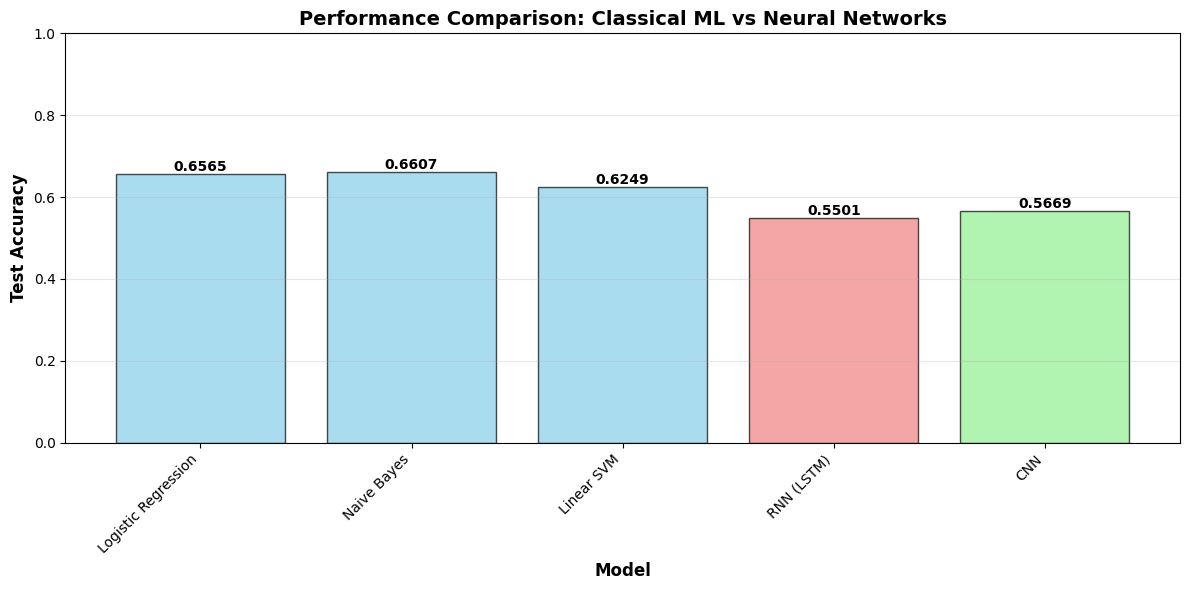

In [19]:
# Visualize comparison
plt.figure(figsize=(12, 6))

models = list(all_results.keys())
accuracies = list(all_results.values())
colors = ['skyblue']*3 + ['lightcoral', 'lightgreen']  # Different colors for classical vs neural

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', alpha=0.7)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=12, fontweight='bold')
plt.title('Performance Comparison: Classical ML vs Neural Networks', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation**

The results show that **classical machine learning models performed better than the neural network models** on this dataset. Naive Bayes achieved the highest accuracy, followed closely by Logistic Regression, while Linear SVM performed slightly worse.

Among the neural models, **CNN performed better than the RNN (LSTM)**, but both achieved lower accuracy than the classical models. This suggests that for this dataset, simpler models using TF IDF features are more effective than the neural models, possibly because the dataset is relatively small and contains limited training examples.

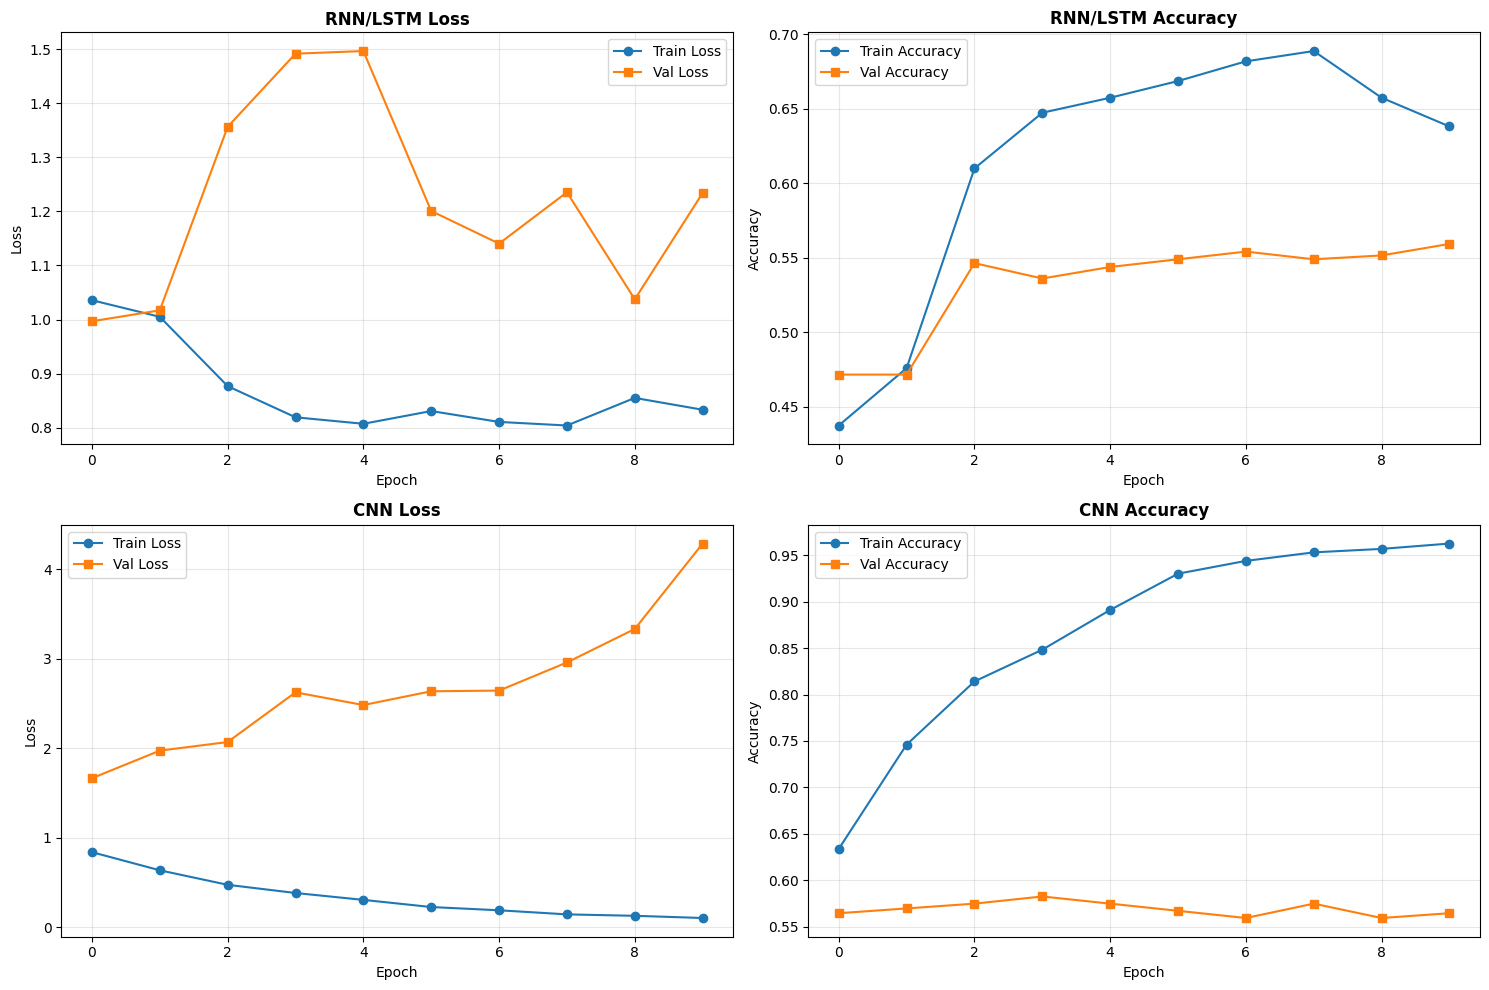

In [20]:
# Plot training history for neural models
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# RNN Loss
axes[0, 0].plot(rnn_train_losses, label='Train Loss', marker='o')
axes[0, 0].plot(rnn_val_losses, label='Val Loss', marker='s')
axes[0, 0].set_title('RNN/LSTM Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# RNN Accuracy
axes[0, 1].plot(rnn_train_accs, label='Train Accuracy', marker='o')
axes[0, 1].plot(rnn_val_accs, label='Val Accuracy', marker='s')
axes[0, 1].set_title('RNN/LSTM Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# CNN Loss
axes[1, 0].plot(cnn_train_losses, label='Train Loss', marker='o')
axes[1, 0].plot(cnn_val_losses, label='Val Loss', marker='s')
axes[1, 0].set_title('CNN Loss', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# CNN Accuracy
axes[1, 1].plot(cnn_train_accs, label='Train Accuracy', marker='o')
axes[1, 1].plot(cnn_val_accs, label='Val Accuracy', marker='s')
axes[1, 1].set_title('CNN Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**

The graphs show that for both the **RNN and CNN models**, the **training loss decreases and training accuracy increases**, meaning the models learn the training data well. However, the **validation loss increases and validation accuracy stays almost constant**, indicating that the models start to **overfit the training data**.

This means the models memorize the training data but do not generalize well to unseen validation data.


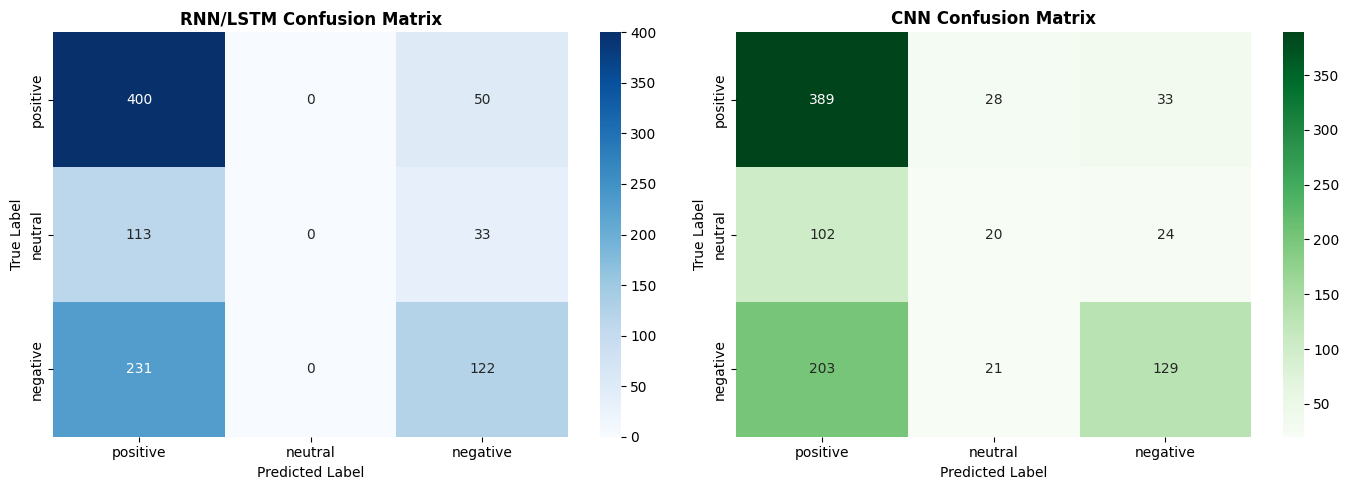

In [21]:
# Confusion matrices for neural models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RNN confusion matrix
cm_rnn = confusion_matrix(rnn_labels, rnn_preds)
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title('RNN/LSTM Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# CNN confusion matrix
cm_cnn = confusion_matrix(cnn_labels, cnn_preds)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title('CNN Confusion Matrix', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

**Interpretation**

The confusion matrices show that the **RNN model struggles to classify the neutral class**, as it almost never predicts neutral correctly. Most neutral and negative tweets are incorrectly classified as positive.

The **CNN model performs slightly better**, correctly predicting some neutral tweets and showing a more balanced distribution across classes. However, both models still confuse negative and positive tweets, indicating difficulty in distinguishing sentiment clearly.


## 7. Key Insights & Comparison

### Classical ML (TF-IDF + Classifiers)
**Pros:**
- Fast training and inference
- Low computational requirements
- Interpretable (feature importance)
- Good baseline performance

**Cons:**
- Ignores word order (bag-of-words)
- Cannot capture long-range dependencies
- Limited semantic understanding
- Fixed-length feature vectors

### RNN/LSTM
**Pros:**
- Processes sequences step-by-step
- Captures temporal relationships
- Handles variable-length input
- Maintains context via hidden states
- Good for long-range dependencies

**Cons:**
- Sequential processing (slower)
- Vanishing/exploding gradients (mitigated by LSTM)
- More parameters to train

### CNN
**Pros:**
- Parallel processing (faster than RNN)
- Captures local patterns (n-grams)
- Fewer parameters than LSTM
- Effective for classification tasks

**Cons:**
- Limited global context
- Fixed kernel sizes
- May miss long-range dependencies

### When to Use Each?
- **Classical ML**: Quick baseline, limited data, need interpretability
- **RNN/LSTM**: Long documents, need full sequential context, sequence generation
- **CNN**: Fast classification, local patterns important, shorter texts

## 8. Test on New Examples

In [22]:
def predict_sentiment(text, model, model_name, vocab, device):
    """Predict sentiment for a given text using neural models"""
    model.eval()

    # Preprocess
    encoded = vocab.encode(text)
    tensor = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)  # Add batch dimension

    # Predict
    with torch.no_grad():
        output = model(tensor)
        probabilities = torch.softmax(output, dim=1)[0]
        predicted_class = torch.argmax(probabilities).item()

    print(f"\n{model_name} Prediction:")
    print(f"Text: {text}")
    print(f"Sentiment: {label_names[predicted_class]} (confidence: {probabilities[predicted_class]:.4f})")
    print(f"Class probabilities:")
    for i, name in enumerate(label_names):
        print(f"  {name}: {probabilities[i]:.4f}")

# Test examples
test_examples = [
    test_texts[0],
    test_texts[10],
    test_texts[20]
]

for example in test_examples:
    print("\n" + "="*80)
    predict_sentiment(example, rnn_model, "RNN/LSTM", vocab, device)
    predict_sentiment(example, cnn_model, "CNN", vocab, device)



RNN/LSTM Prediction:
Text: ah ka s3 prison mpo er
Sentiment: positive (confidence: 0.7988)
Class probabilities:
  positive: 0.7988
  neutral: 0.1592
  negative: 0.0420

CNN Prediction:
Text: ah ka s3 prison mpo er
Sentiment: positive (confidence: 0.9898)
Class probabilities:
  positive: 0.9898
  neutral: 0.0095
  negative: 0.0007


RNN/LSTM Prediction:
Text: fa ma mi ehhh 😂
Sentiment: positive (confidence: 0.7452)
Class probabilities:
  positive: 0.7452
  neutral: 0.1581
  negative: 0.0967

CNN Prediction:
Text: fa ma mi ehhh 😂
Sentiment: positive (confidence: 0.9908)
Class probabilities:
  positive: 0.9908
  neutral: 0.0092
  negative: 0.0001


RNN/LSTM Prediction:
Text: sɛ ndc foɔ diɛɛ bɛbrɛɛ naa ɛgyimi
Sentiment: positive (confidence: 0.8948)
Class probabilities:
  positive: 0.8948
  neutral: 0.0802
  negative: 0.0250

CNN Prediction:
Text: sɛ ndc foɔ diɛɛ bɛbrɛɛ naa ɛgyimi
Sentiment: positive (confidence: 0.9996)
Class probabilities:
  positive: 0.9996
  neutral: 0.0001
  negativ

## Summary

This notebook demonstrated three approaches to text classification:

1. **Classical ML** provides a strong baseline using TF-IDF features but ignores word order
2. **RNN/LSTM** captures sequential patterns and long-range dependencies through recurrent connections
3. **CNN** efficiently extracts local n-gram features using convolution filters

**Key Takeaways:**
- Classical ML is fast but limited by bag-of-words assumption
- RNNs excel at modeling sequential dependencies but are computationally expensive
- CNNs offer a good balance between performance and efficiency for text classification
- The choice depends on your specific task, data, and computational constraints

**Implementation Notes:**
- PyTorch provides flexible model building with custom architectures
- DataLoader handles batching and padding efficiently
- GPU acceleration significantly speeds up training
- Proper evaluation metrics are crucial for understanding model performance

**Next Steps:**
- Try bidirectional LSTM (Bi-LSTM) for better context capture
- Experiment with multiple CNN filter sizes simultaneously
- Use pre-trained embeddings (Word2Vec, GloVe, FastText)
- Explore hybrid models (CNN + LSTM)
- Consider attention mechanisms
- Try transformer-based models (BERT, RoBERTa) for state-of-the-art performance (Next Lecture!)

# Further Exploration

**For more example on understanding and implementing sequence classification, check this repository:**

```https://github.com/bentrevett/pytorch-sentiment-analysis```

## Assigment

The AfriSenti dataset is a large-scale benchmark for sentiment analysis in African languages, containing more than 110,000 annotated tweets across 14 languages with three sentiment labels: positive, negative, and neutral . The dataset was introduced for SemEval-2023 Task 12, which evaluated sentiment classification systems for low-resource African languages

#### Dataset resources:

1. GitHub: https://github.com/afrisenti-semeval/afrisent-semeval-2023

2. HuggingFace: https://huggingface.co/datasets/shmuhammad/AfriSenti-twitter-sentiment
You will build and compare sentiment classification models using this dataset.

Select one language from the AfriSenti dataset (e.g., Hausa, Yoruba, Igbo, Swahili, or Nigerian Pidgin) and train the model using 3 approaches:

1. Any classical Machine Learning
2. CNN
3. RNN


### Analysis and Comparison

Answer the following questions:

**1. Which modeling approach performs best on your selected language?**

The Naive Bayes model performs best, achieving the highest test accuracy of about 66 percent, followed closely by Logistic Regression.

**2. Why do you think this model performs better than the others?**


Naive Bayes works well with TF IDF features and small text datasets. The dataset is relatively small, so simpler models can learn useful patterns more effectively than neural networks, which usually require larger datasets to perform well.

**3. How does your best model compare with the reported results from the AfriSenti shared task or baseline systems?**

My best model, **Naive Bayes**, achieved about **66 percent accuracy** on the Twi dataset. When compared with the AfriSenti shared task results for Twi, most pretrained transformer models such as **AfriBERTa, XLM R, and AfroXLMR** achieve scores roughly between **56 percent and 65 percent**.

This means the performance of my model is **comparable and slightly higher than some reported baseline results**. However, the comparison should be interpreted carefully because the AfriSenti results are usually reported using **weighted F1 score**, while my experiment reports **accuracy**, and the benchmark models are trained using larger pretrained language models that capture richer contextual information.



**4. What challenges did you observe when working with this African language dataset?**

Several challenges were observed, including **class imbalance**, limited dataset size, informal language usage, and mixed expressions such as slang and emojis. These factors make it harder for models to learn clear sentiment patterns and correctly classify all sentiment classes, especially the neutral class.


Link 1--------https://www.skills.google/public_profiles/241e9d7c-8afc-4fe4-8821-81128ae3c8e3/badges/22682792

Link 2----------https://www.skills.google/public_profiles/241e9d7c-8afc-4fe4-8821-81128ae3c8e3/badges/22672254

